
# 🎙️ Emotion Recognition from Speech

**Objective:** Recognize human emotions (e.g., happy, angry, sad, neutral, calm, fearful, disgust, surprised) from speech audio.

**Approach:** Deep learning + speech signal processing.

**Pipeline overview:**
1. Load and explore a speech-emotion dataset (RAVDESS / TESS / EMO-DB).
2. Extract acoustic features — **MFCCs**, Chroma, Mel-spectrogram, Zero-Crossing-Rate, RMS energy (with optional delta-MFCCs).
3. Apply data augmentation (noise injection, pitch shift, time stretch) to improve generalization.
4. Build and train a **CNN + LSTM (CNN-BiLSTM)** deep learning classifier.
5. Evaluate with accuracy, confusion matrix, and classification report.
6. Save the trained model and run inference on a new audio clip.

---

## 📦 Supported datasets

| Dataset | Description | Where to get it |
|---|---|---|
| **RAVDESS** | Ryerson Audio-Visual Database of Emotional Speech and Song. 24 actors, 8 emotions. | https://zenodo.org/record/1188976 (or Kaggle: `uwrfkaggler/ravdess-emotional-speech-audio`) |
| **TESS** | Toronto Emotional Speech Set. 2 actresses, 7 emotions. | Kaggle: `ejlok1/toronto-emotional-speech-set-tess` |
| **EMO-DB** | Berlin Database of Emotional Speech (German). 10 actors, 7 emotions. | http://emodb.bilderbar.info/ or Kaggle: `piyushagni5/berlin-database-of-emotional-speech-emodb` |

> **Before running:** download one (or more) of the datasets above, unzip it, and point the `DATASET_PATHS` dictionary in the **Configuration** cell to the correct folder(s). The notebook auto-detects which datasets are present and parses their filename conventions automatically.


## 1. Install & Import Libraries

In [1]:
# Run once. Comment out if already installed.
# !pip install librosa soundfile numpy pandas scikit-learn tensorflow matplotlib seaborn tqdm


In [2]:
import os
import glob
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Librosa:", librosa.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow: 2.20.0
Librosa: 0.11.0
GPU available: False


## 2. Configuration

### Download RAVDESS Dataset from Kaggle

To download the RAVDESS dataset, you'll need a Kaggle API key. Follow these steps:

1.  Go to [Kaggle](https://www.kaggle.com/) and log in.
2.  Click on your profile picture, then 'My Account'.
3.  Scroll down to the 'API' section and click 'Create New API Token'. This will download a `kaggle.json` file.
4.  Upload this `kaggle.json` file to your Google Colab environment. You can do this by clicking the folder icon on the left panel, then the upload icon, and selecting `kaggle.json`. Ensure it's placed in the `/root/.kaggle/` directory. Alternatively, you can use `files.upload()` from `google.colab` to upload it, and then move it to the correct directory.

In [4]:
import os
from google.colab import files

# Create .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Upload kaggle.json (if not already uploaded and in the correct place)
# files.upload() # Uncomment and run this line if you need to upload kaggle.json

# Move kaggle.json to the correct directory (if uploaded to root)
# !mv kaggle.json ~/.kaggle/

# Set permissions
!chmod 600 ~/.kaggle/kaggle.json

# Create a 'data' directory for datasets
!mkdir -p data

# Download RAVDESS dataset from Kaggle
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio -p data/

# Unzip the dataset
!unzip -q data/ravdess-emotional-speech-audio.zip -d data/RAVDESS

print("RAVDESS dataset downloaded and unzipped to data/RAVDESS")

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:26<00:00, 17.2MB/s]

RAVDESS dataset downloaded and unzipped to data/RAVDESS


Now that the RAVDESS dataset is downloaded, we need to update the `DATASET_PATHS` variable to reflect its correct location. The code below modifies the existing `DATASET_PATHS` to ensure the notebook can find the RAVDESS data.

In [6]:
DATASET_PATHS["RAVDESS"] = "data/RAVDESS"
print(f"Updated RAVDESS path in DATASET_PATHS: {DATASET_PATHS['RAVDESS']}")

Updated RAVDESS path in DATASET_PATHS: data/RAVDESS


In [12]:
# ----------------------------------------------------------------------------
# Point these to the folders where you extracted each dataset (leave as None /
# remove the key if you don't have that dataset). The loader below will only
# use the datasets whose path exists.
# ----------------------------------------------------------------------------
DATASET_PATHS = {
    "RAVDESS": "data/RAVDESS/ravdess-emotional-speech-audio",   # contains Actor_01 ... Actor_24 sub-folders of .wav files
    "TESS":    "data/TESS",      # contains .wav files named like OAF_back_angry.wav
    "EMODB":   "data/EMODB",     # contains .wav files named like 03a01Fa.wav
}

SAMPLE_RATE   = 22050      # Hz, audio resample rate
DURATION      = 3.0        # seconds, fixed clip length (pad/truncate)
N_MFCC        = 40         # number of MFCC coefficients
N_MELS        = 128        # mel bands for mel-spectrogram
TEST_SIZE     = 0.15
VAL_SIZE      = 0.15
BATCH_SIZE    = 32
EPOCHS        = 60
AUGMENT       = True       # set False to skip augmentation (faster, less data)

# Unified emotion label set we will map every dataset onto
EMOTION_LABELS = [
    "neutral", "calm", "happy", "sad",
    "angry", "fearful", "disgust", "surprised"
]


## 3. Dataset Parsing

Each dataset encodes the emotion label differently in its filename. We write one parser per
dataset and merge everything into a single dataframe with columns `path` and `emotion`.


In [8]:
def parse_ravdess(root):
    """RAVDESS filename: 03-01-06-01-02-01-12.wav
    3rd number (index 2) = emotion code:
    01=neutral 02=calm 03=happy 04=sad 05=angry 06=fearful 07=disgust 08=surprised
    """
    code_map = {
        "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
        "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised",
    }
    rows = []
    for f in glob.glob(os.path.join(root, "**", "*.wav"), recursive=True):
        parts = os.path.basename(f).split("-")
        if len(parts) >= 3 and parts[2] in code_map:
            rows.append({"path": f, "emotion": code_map[parts[2]]})
    return rows


def parse_tess(root):
    """TESS filename example: OAF_back_angry.wav -> last token (before .wav) is the emotion.
    TESS uses 'ps' for pleasant_surprise -> map to 'surprised'.
    """
    code_map = {
        "neutral": "neutral", "calm": "calm", "happy": "happy", "sad": "sad",
        "angry": "angry", "fear": "fearful", "disgust": "disgust",
        "ps": "surprised", "pleasant_surprise": "surprised", "surprise": "surprised",
    }
    rows = []
    for f in glob.glob(os.path.join(root, "**", "*.wav"), recursive=True):
        stem = os.path.splitext(os.path.basename(f))[0].lower()
        tag = stem.split("_")[-1]
        if tag in code_map:
            rows.append({"path": f, "emotion": code_map[tag]})
    return rows


def parse_emodb(root):
    """EMO-DB filename example: 03a01Fa.wav -> 6th character is the emotion code.
    W=anger L=boredom E=disgust A=anxiety/fear F=happiness T=sadness N=neutral
    (EMO-DB has no 'calm'/'surprised' categories; 'boredom' is mapped to 'neutral'-adjacent
    but kept as its own class only if you want a 7-class EMO-DB-only run.)
    """
    code_map = {
        "W": "angry", "L": "boredom", "E": "disgust", "A": "fearful",
        "F": "happy", "T": "sad", "N": "neutral",
    }
    rows = []
    for f in glob.glob(os.path.join(root, "**", "*.wav"), recursive=True):
        stem = os.path.splitext(os.path.basename(f))[0]
        if len(stem) >= 6 and stem[5] in code_map:
            rows.append({"path": f, "emotion": code_map[stem[5]]})
    return rows


PARSERS = {"RAVDESS": parse_ravdess, "TESS": parse_tess, "EMODB": parse_emodb}

all_rows = []
for name, path in DATASET_PATHS.items():
    if os.path.isdir(path):
        rows = PARSERS[name](path)
        print(f"{name}: found {len(rows)} files at '{path}'")
        all_rows.extend(rows)
    else:
        print(f"{name}: path '{path}' not found, skipping.")

df = pd.DataFrame(all_rows)
if df.empty:
    raise RuntimeError(
        "No dataset files found. Download RAVDESS/TESS/EMO-DB, set the correct "
        "folder paths in DATASET_PATHS above, then re-run this cell."
    )

# Drop rare classes like 'boredom' if they only come from one dataset and are too sparse,
# or simply keep them — here we keep only the 8 unified emotions for consistency.
df = df[df["emotion"].isin(EMOTION_LABELS)].reset_index(drop=True)
print("\nTotal usable samples:", len(df))
df["emotion"].value_counts()


RAVDESS: found 2880 files at 'data/RAVDESS'
TESS: path 'data/TESS' not found, skipping.
EMODB: path 'data/EMODB' not found, skipping.

Total usable samples: 2880


,count
emotion,
angry,384
fearful,384
sad,384
calm,384
disgust,384
happy,384
surprised,384
neutral,192


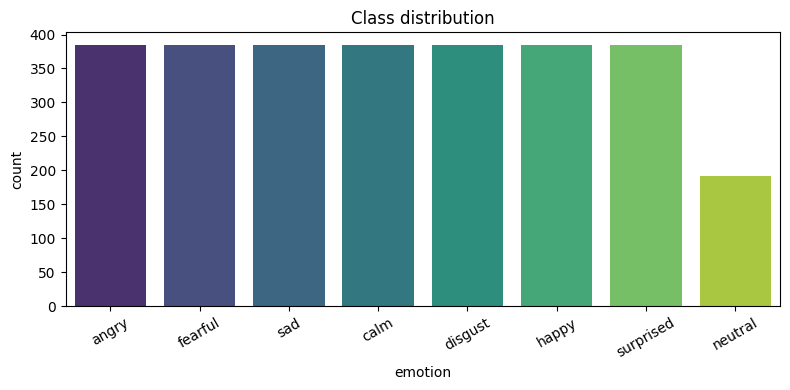

In [9]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="emotion", order=df["emotion"].value_counts().index, palette="viridis")
plt.title("Class distribution")
plt.xticks(rotation=30)
plt.ylabel("count")
plt.tight_layout()
plt.show()


## 4. Audio Exploration

Quick sanity check: load one sample per emotion and look at its waveform + MFCCs.


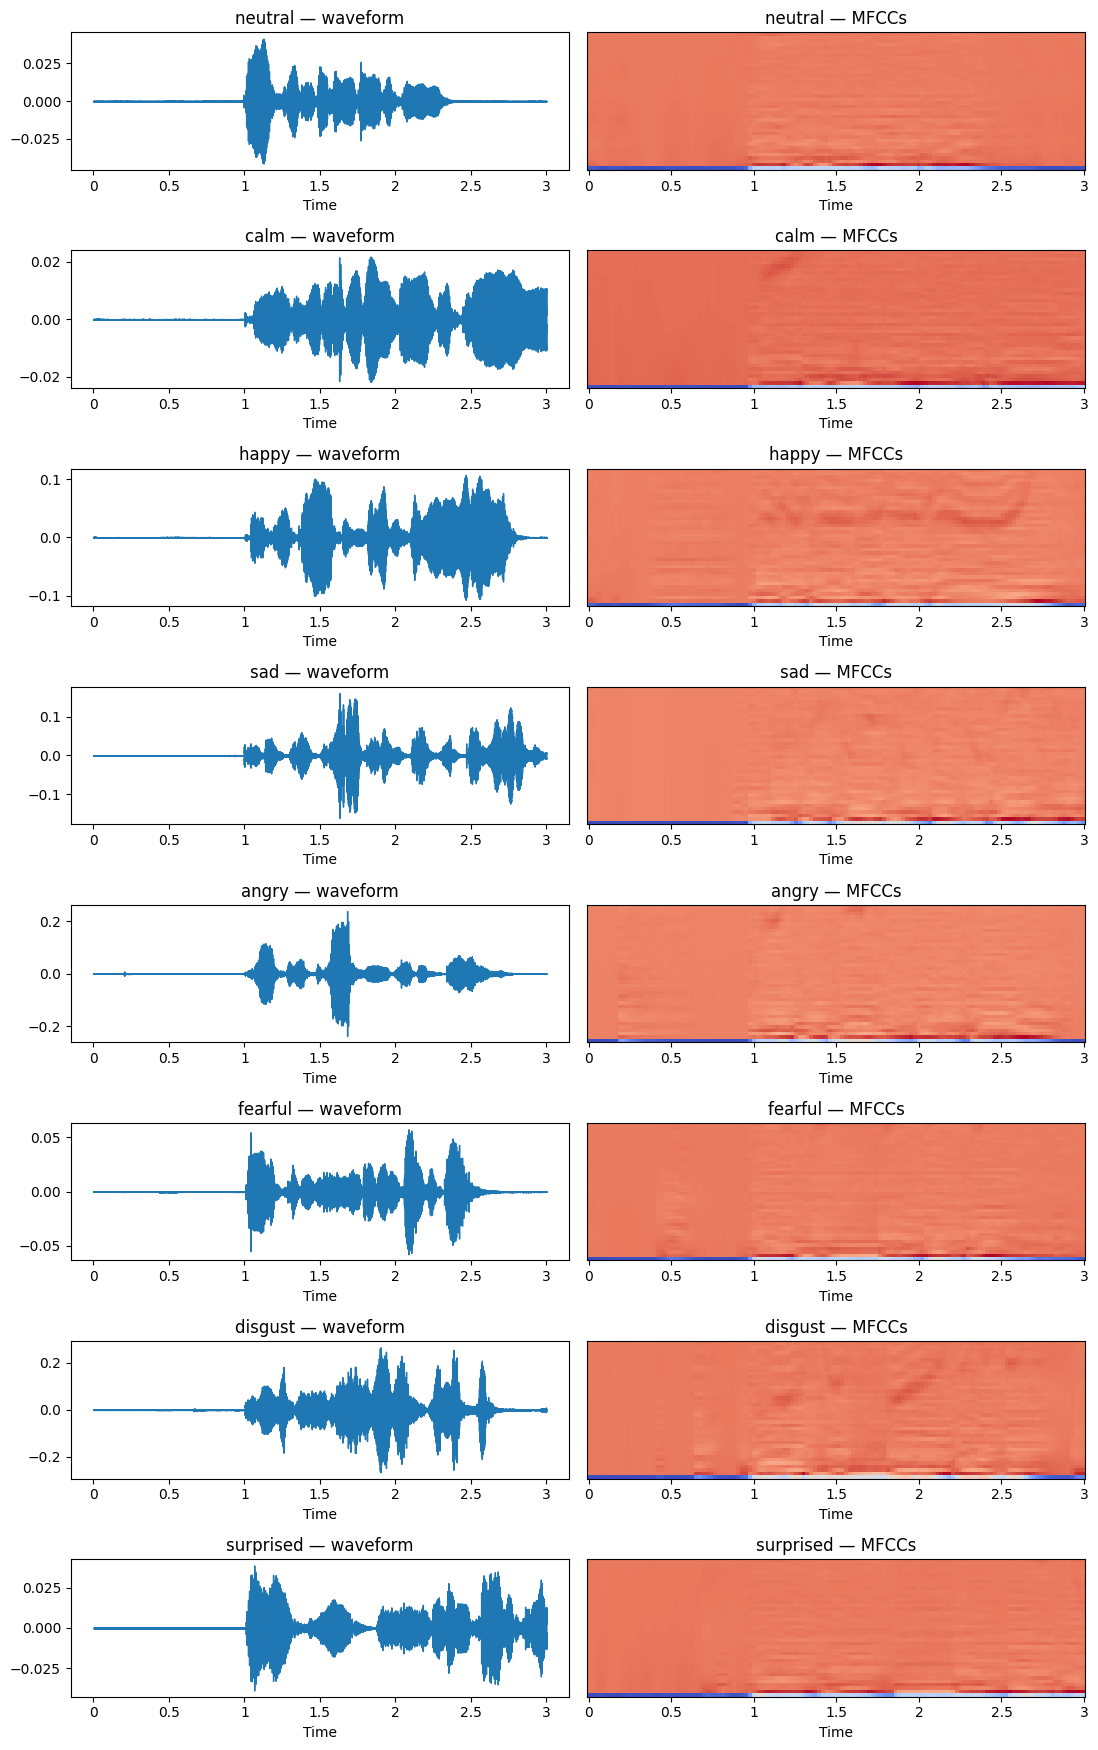

In [10]:
def load_audio(path, sr=SAMPLE_RATE, duration=DURATION):
    y, _ = librosa.load(path, sr=sr, duration=duration)
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y


fig, axes = plt.subplots(len(EMOTION_LABELS), 2, figsize=(11, 2.2 * len(EMOTION_LABELS)))
for i, emo in enumerate(EMOTION_LABELS):
    sample = df[df["emotion"] == emo]
    if sample.empty:
        for j in range(2):
            axes[i, j].axis("off")
        continue
    path = sample.iloc[0]["path"]
    y = load_audio(path)
    mfcc = librosa.feature.mfcc(y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC)

    librosa.display.waveshow(y, sr=SAMPLE_RATE, ax=axes[i, 0])
    axes[i, 0].set_title(f"{emo} — waveform")
    img = librosa.display.specshow(mfcc, sr=SAMPLE_RATE, x_axis="time", ax=axes[i, 1])
    axes[i, 1].set_title(f"{emo} — MFCCs")
plt.tight_layout()
plt.show()


## 5. Data Augmentation

To make the model robust to recording conditions and to combat class imbalance, we add three
classic waveform-level augmentations:
- **Noise injection** — add small Gaussian noise.
- **Pitch shifting** — shift pitch up/down by a couple of semitones.
- **Time stretching** — slightly speed up / slow down without changing pitch.


In [14]:
def add_noise(y, noise_factor=0.005):
    noise = np.random.randn(len(y))
    return y + noise_factor * noise


def pitch_shift(y, sr=SAMPLE_RATE, n_steps=None):
    if n_steps is None:
        n_steps = np.random.uniform(-2, 2)
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)


def time_stretch(y, rate=None):
    if rate is None:
        rate = np.random.uniform(0.9, 1.1)
    y_stretched = librosa.effects.time_stretch(y, rate=rate)
    target_len = int(SAMPLE_RATE * DURATION)
    if len(y_stretched) < target_len:
        y_stretched = np.pad(y_stretched, (0, target_len - len(y_stretched)))
    else:
        y_stretched = y_stretched[:target_len]
    return y_stretched


def augment_audio(y):
    """Randomly apply one augmentation, returns augmented waveform."""
    choice = np.random.choice(["noise", "pitch", "stretch"])
    if choice == "noise":
        return add_noise(y)
    elif choice == "pitch":
        return pitch_shift(y)
    else:
        return time_stretch(y)

## 6. Feature Extraction

For every clip we compute, frame-by-frame, and stack into one feature matrix of shape
`(n_frames, n_features)`:

- **MFCCs** (40 coefficients) — captures timbral/spectral-envelope information correlated with
  vocal-tract shape, the single most informative feature for speech emotion.
- **Delta-MFCCs** — first derivative of MFCCs, captures how the spectral envelope changes over
  time (useful for prosodic cues like rising/falling intonation).
- **Chroma STFT** — pitch-class energy, related to intonation/pitch contour.
- **Mel-spectrogram** (log-scaled) — perceptual loudness across frequency bands.
- **Zero-Crossing-Rate** and **RMS energy** — simple but effective indicators of voicing and
  loudness/intensity, which correlate strongly with arousal (e.g. angry/happy vs sad/calm).

The frame-level sequence (instead of a single averaged vector) is what lets us feed the data into
an LSTM/CNN-LSTM model that can learn *temporal* dynamics of emotional speech, not just a static
fingerprint.


In [15]:
N_FRAMES_TARGET = 130  # ~3s at sr=22050, hop_length=512 -> pad/truncate frames to this

def extract_features(y, sr=SAMPLE_RATE):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)                  # (40, T)
    delta_mfcc = librosa.feature.delta(mfcc)                                # (40, T)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)                        # (12, T)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)         # (128, T)
    log_mel = librosa.power_to_db(mel)
    zcr = librosa.feature.zero_crossing_rate(y)                            # (1, T)
    rms = librosa.feature.rms(y=y)                                          # (1, T)

    # Stack along the feature axis -> shape (n_features, T)
    features = np.vstack([mfcc, delta_mfcc, chroma, log_mel, zcr, rms])
    # Transpose -> (T, n_features) so time is the sequence axis (good for LSTM/CNN1D)
    features = features.T

    # Pad / truncate the time axis to a fixed length
    if features.shape[0] < N_FRAMES_TARGET:
        pad_width = N_FRAMES_TARGET - features.shape[0]
        features = np.pad(features, ((0, pad_width), (0, 0)), mode="constant")
    else:
        features = features[:N_FRAMES_TARGET, :]

    return features.astype(np.float32)


# Quick shape check
_y = load_audio(df.iloc[0]["path"])
_f = extract_features(_y)
print("Feature matrix shape (time_steps, n_features):", _f.shape)
N_FEATURES = _f.shape[1]


Feature matrix shape (time_steps, n_features): (130, 222)


In [16]:
def build_dataset(dataframe, augment=AUGMENT):
    X, y_labels = [], []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Extracting features"):
        y = load_audio(row["path"])
        X.append(extract_features(y))
        y_labels.append(row["emotion"])

        if augment:
            y_aug = augment_audio(y)
            X.append(extract_features(y_aug))
            y_labels.append(row["emotion"])

    return np.array(X), np.array(y_labels)


X, y_labels = build_dataset(df, augment=AUGMENT)
print("X shape:", X.shape, " y shape:", y_labels.shape)


Extracting features:   0%|          | 0/2880 [00:00<?, ?it/s]

X shape: (5760, 130, 222)  y shape: (5760,)


## 7. Encode Labels, Scale Features, Train/Val/Test Split

In [17]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
n_classes = len(le.classes_)
print("Classes:", list(le.classes_))

y_onehot = tf.keras.utils.to_categorical(y_encoded, num_classes=n_classes)

# Train / val / test split (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_onehot, test_size=(TEST_SIZE + VAL_SIZE), stratify=y_encoded, random_state=SEED
)
strat_temp = np.argmax(y_temp, axis=1)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=TEST_SIZE / (TEST_SIZE + VAL_SIZE),
    stratify=strat_temp, random_state=SEED
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


Classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
Train: (4032, 130, 222)  Val: (864, 130, 222)  Test: (864, 130, 222)


In [18]:
# Standardize features (fit only on training data to avoid leakage)
n_train, T, F = X_train.shape
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, F))

def scale(X_):
    shp = X_.shape
    return scaler.transform(X_.reshape(-1, shp[-1])).reshape(shp)

X_train = scale(X_train)
X_val   = scale(X_val)
X_test  = scale(X_test)


## 8. Build the Deep Learning Model — CNN + BiLSTM

Architecture rationale:
- **1D Conv layers** scan across the time axis to learn local spectro-temporal patterns
  (similar to how 2D CNNs learn local patterns in images) and reduce sequence length.
- **BiLSTM layers** then model long-range temporal dependencies in both directions — emotional
  cues in speech (e.g. a rising pitch contour signalling surprise) unfold over time, so a
  recurrent layer captures that dynamic better than a purely convolutional/pooling model.
- **Dense + Softmax** head performs final multi-class classification.


In [19]:
def build_model(input_shape, n_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(256, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(64))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="CNN_BiLSTM_SER")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_model((X_train.shape[1], X_train.shape[2]), n_classes)
model.summary()


Model: "CNN_BiLSTM_SER"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 130, 222)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 130, 128)       │       142,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 130, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 65, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 65, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 65, 256)        │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 65, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 883,976 (3.37 MB)

 Trainable params: 883,208 (3.37 MB)

 Non-trainable params: 768 (3.00 KB)

## 9. Train the Model

In [20]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
)
checkpoint = callbacks.ModelCheckpoint(
    "best_emotion_model.keras", monitor="val_accuracy", save_best_only=True, verbose=0
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1,
)


Epoch 1/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 63s 432ms/step - accuracy: 0.3264 - loss: 1.7832 - val_accuracy: 0.3785 - val_loss: 1.7152 - learning_rate: 0.0010
Epoch 2/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 48s 379ms/step - accuracy: 0.4514 - loss: 1.5139 - val_accuracy: 0.5035 - val_loss: 1.3664 - learning_rate: 0.0010
Epoch 3/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 46s 365ms/step - accuracy: 0.5357 - loss: 1.3002 - val_accuracy: 0.6019 - val_loss: 1.1215 - learning_rate: 0.0010
Epoch 4/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 83s 375ms/step - accuracy: 0.6027 - loss: 1.1119 - val_accuracy: 0.5938 - val_loss: 1.1288 - learning_rate: 0.0010
Epoch 5/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 46s 367ms/step - accuracy: 0.6595 - loss: 0.9681 - val_accuracy: 0.6771 - val_loss: 0.9581 - learning_rate: 0.0010
Epoch 6/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 83s 371ms/step - accuracy: 0.7180 - loss: 0.8194 - val_accuracy: 0.7245 - val_loss: 0.8280 - learning_rate: 0.0010
Epoch 7/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 49s 388ms/step - accuracy: 0.7

## 10. Training Curves

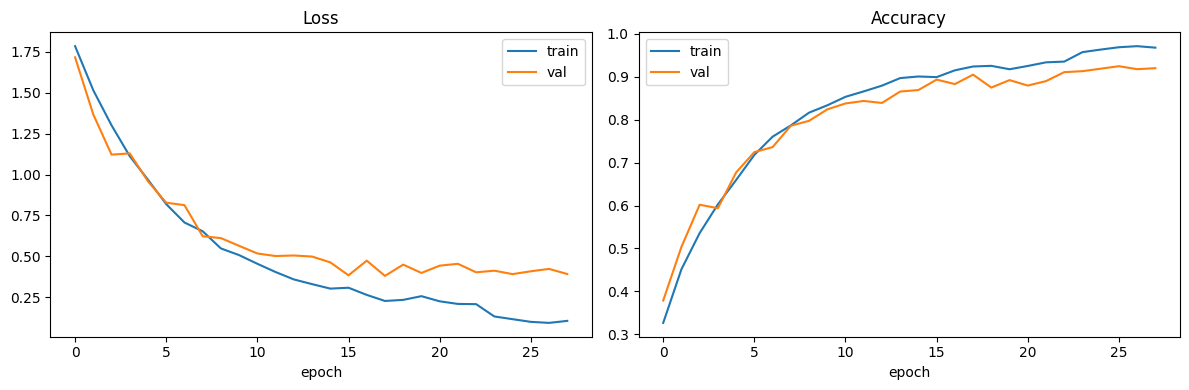

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Evaluation on the Held-out Test Set

In [22]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))


Test accuracy: 0.9039
Test loss:     0.3533
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step

Classification report:

              precision    recall  f1-score   support

       angry       0.92      0.95      0.94       115
        calm       0.83      0.95      0.88       115
     disgust       0.97      0.90      0.94       115
     fearful       0.84      0.88      0.86       116
       happy       0.94      0.90      0.92       115
     neutral       0.89      0.83      0.86        58
         sad       0.89      0.83      0.86       115
   surprised       0.96      0.96      0.96       115

    accuracy                           0.90       864
   macro avg       0.91      0.90      0.90       864
weighted avg       0.91      0.90      0.90       864



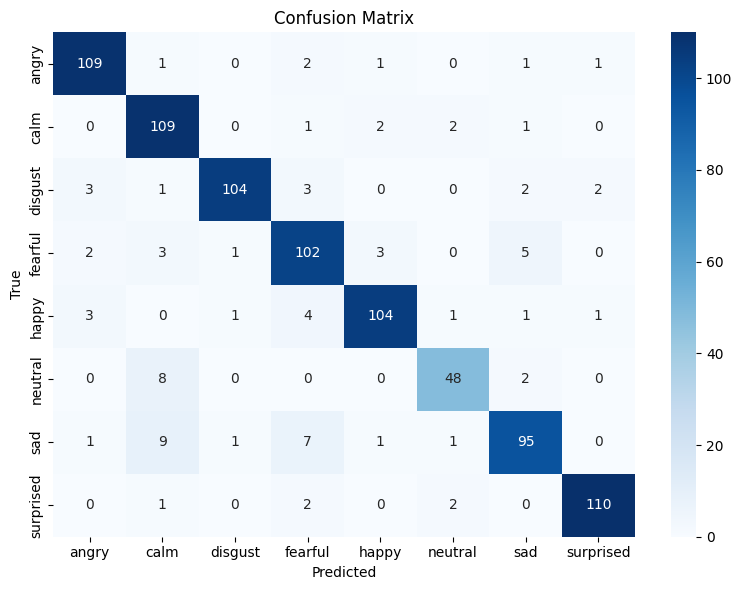

In [23]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 12. Save the Model & Preprocessing Artifacts

In [24]:
import joblib

model.save("emotion_recognition_model.keras")
joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Saved: emotion_recognition_model.keras, feature_scaler.pkl, label_encoder.pkl")


Saved: emotion_recognition_model.keras, feature_scaler.pkl, label_encoder.pkl


## 13. Inference — Predict Emotion from a New Audio File

Run this cell on any `.wav` file to get the predicted emotion and class probabilities.


In [25]:
def predict_emotion(file_path, model=model, scaler=scaler, label_encoder=le):
    y = load_audio(file_path)
    feats = extract_features(y)                       # (T, F)
    feats = scaler.transform(feats)                    # scale
    feats = np.expand_dims(feats, axis=0)               # (1, T, F)

    probs = model.predict(feats, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    prob_dict = {label_encoder.classes_[i]: float(probs[i]) for i in range(len(probs))}
    prob_dict = dict(sorted(prob_dict.items(), key=lambda kv: kv[1], reverse=True))
    return pred_label, prob_dict


# Example usage (replace with a real path to test):
# label, probs = predict_emotion("path/to/your_audio.wav")
# print("Predicted emotion:", label)
# for emo, p in probs.items():
#     print(f"  {emo:>10s}: {p:.3f}")


## 14. Notes, Tips & Next Steps

- **Imbalanced classes**: if some emotions have far fewer samples (common with TESS/EMO-DB
  mixes), consider class weights (`class_weight` in `model.fit`) or oversampling minority
  classes via augmentation.
- **Cross-corpus generalization**: training on a single dataset (e.g. RAVDESS only) often
  overfits to that dataset's actors/recording conditions. Combining RAVDESS + TESS + EMO-DB (as
  this notebook supports) improves robustness, but mind that EMO-DB is German while
  RAVDESS/TESS are English — emotion in speech is fairly language-agnostic acoustically, but
  results may still vary cross-lingually.
- **Alternative architectures** worth trying:
  - Pure 2D-CNN on the log-mel spectrogram treated as an "image".
  - Attention-based pooling instead of the final BiLSTM's last hidden state.
  - Pretrained audio embeddings (e.g. Wav2Vec2 / HuBERT) fine-tuned for emotion classification,
    which usually outperform hand-crafted MFCC pipelines on larger datasets.
- **Real-time inference**: wrap `predict_emotion` with a microphone-streaming loop (e.g. using
  `sounddevice`) to build a live emotion-recognition demo.
